# Les transformations du son de base

***Origine physique du son***

Le son provient de vibrations mécaniques créant des variations locales de la pression dans l'air au cours du temps.

Les microphones captent l'onde analogique continue et la carte son l'échantillonne à intervalles réguliers.

***Mono vs Stéréo***

Le stéréo contient deux canaux distincts afin de restituer un effet spatial.

La librairie Librosa convertit le son en mono, car l'analyse ne nécessite pas de spatialisation et cela doublerait la quantité de données à analyser. Le passage en mono ne diminue pas la quantité d'information.

#### Formules mathématiques

$$ x[n] = x(n \cdot T_s) = x\left(\frac{n}{sr}\right) \quad \text{avec } n \in [0, N-1] $$

$x(t)$ est le signal acoustique continu d'origine
$n$ est le numéro de l'échantillon temporel
$sr$ est le taux d'échantillonage
$N$ est le nombre total d'échantillons

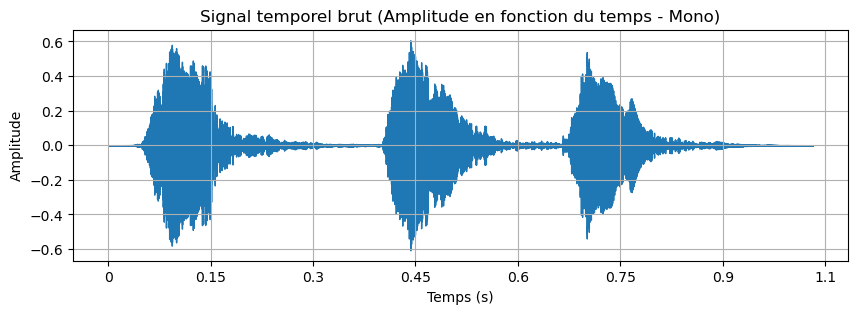

In [4]:
import librosa
import matplotlib.pyplot as plt

# Chargement du fichier audio
y, sr = librosa.load("dog.mp3", sr=22050, mono=True)

# Representation du signal temporel brut
plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Signal temporel brut (Amplitude en fonction du temps - Mono)")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

***Paramètres***

$sr$ : taux d'échantillonage (par défaut 22050Hz)

$mono = True$ : fusione les canaux stéréo

***Output***

$y$ : tableau 1D normalisé entre -1 et 1 où chaque y correspond à la pression mesurée à l'instant tn

$sr$ : taux d'échantillonage

***Taux d'échantillonage***

Si la norme audio CD utilise généralement un échantillonnage à 44,1 kHz pour couvrir l'intégralité du champ audible humain (jusqu'à 20 kHz), la parole humaine concentre la totalité de ses composantes acoustiques et formants sous la barre des 8 000 Hz. D'après le théorème de Nyquist-Shannon ($f_{\max} = sr / 2$), une fréquence de 22 050 Hz permet de restituer parfaitement le signal jusqu'à 11 025 Hz. Ce choix permet de diviser la taille des données par deux sans aucune perte d'information utile pour la reconnaissance vocale.

# Conversion

La DFT (transormée de Fourier classique) décompose un signal en une somme de sinusoides pures, mais sur un fichier audio elle calcule une moyenne globale des fréquences or la parole est un signal dont les fréquences changent constamment

C'est pour cela qu'on utilise la STFT (transormée de Fourier à court terme) qui va découper le signal en petites tranches d'environ 20 à 30 ms et applique la DFT sur chaque tranches

Pour éviter les discontinuités mathématiques aux bords d'une fenêtre découpée,on applique une fonction de fenêtrage qui atténue les bords à 0.

généralement la fenêtre de Hann :$$w[n] = 0{,}5 \cdot \left(1 - \cos\left(\frac{2\pi n}{N}\right)\right)$$Cette fonction démarre à 0, monte à 1 au milieu, et retombe à 0 à l'extrémité.

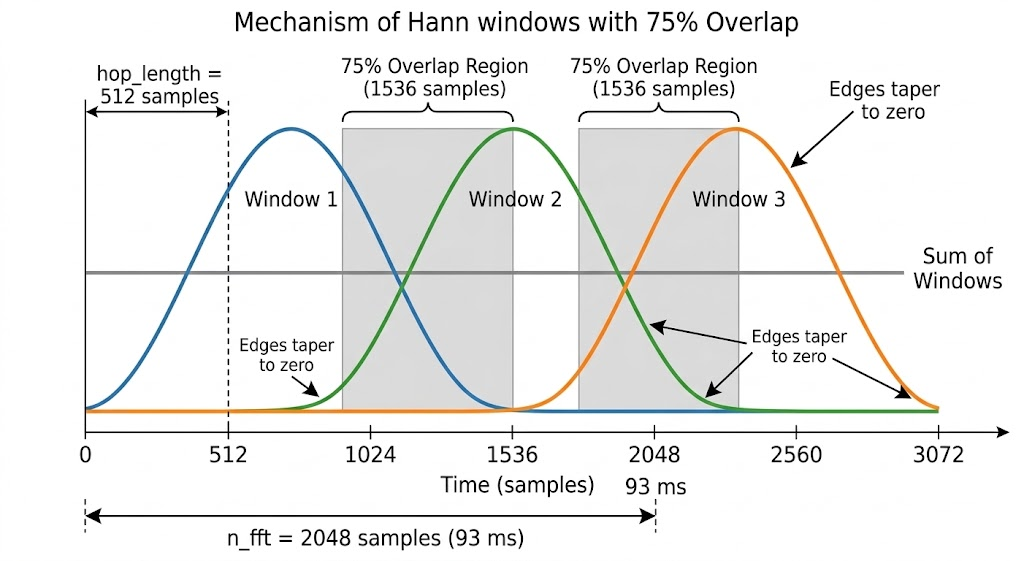

Le problème est que les données audio situées au début et à la fin de la fenêtre voient leur amplitude multipliée par des valeurs proches de 0 ; elles sont donc presque totalement écrasées et perdues.

Sans ce chevauchement, on perdrait l'information situé aux extrémités des fenêtres

En avançant de $hop\_length = 512$ pour une fenêtre $n\_fft = 2048$, chaque tranche recouvre $75\,\%$ de la tranche précédente ($1 - \frac{512}{2048} = 0{,}75$)

DFT (Signal entier) :$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-i 2\pi \frac{k n}{N}}$$

STFT (Fenêtres locales avec chevauchement) :$$X[m, k] = \sum_{n=0}^{N_{\text{fft}}-1} x[n + m \cdot hop\_length] \cdot w[n] \cdot e^{-i 2\pi \frac{k n}{N_{\text{fft}}}}$$

$x[n]$ : Le signal temporel discret échantillonné

$w[n]$ : La fonction de fenêtrage glissant dans le temps

$m$ : L'indice temporel de la trame (frame)

$k$ : L'indice de la composante fréquentielle (bin)

$hop\_length$ : Le décalage en échantillons entre chaque trame successive.

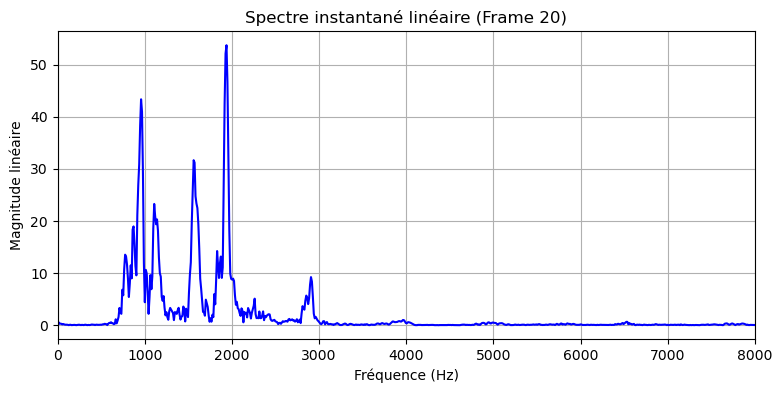

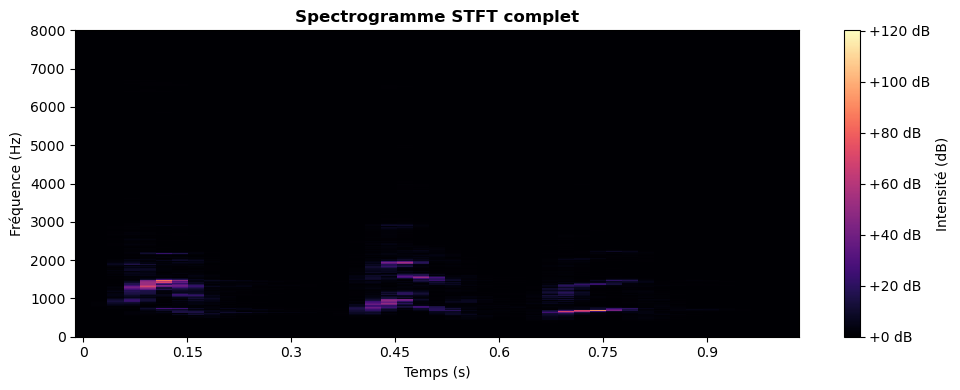

In [12]:
import numpy as np

# Calcul de la STFT
stft = librosa.stft(y, n_fft=2048, hop_length=512, win_length=2048)
magnitude = np.abs(stft)

frame_idx = 20
instant_spectrum = magnitude[:, frame_idx]
freq_bins = librosa.fft_frequencies(sr=sr, n_fft=2048)

plt.figure(figsize=(9, 4))
plt.plot(freq_bins, instant_spectrum, color='b')
plt.title(f"Spectre instantané linéaire (Frame {frame_idx})")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Magnitude linéaire")
plt.xlim(0, 8000)
plt.grid(True)
plt.show()


stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    magnitude, sr=sr, hop_length=hop_length, x_axis="time", y_axis="hz"
)
plt.colorbar(format="%+2.0f dB", label="Intensité (dB)")
plt.title("Spectrogramme STFT complet", fontweight="bold")
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Hz)")
plt.ylim(0, 8000)  # Focus sur les fréquences informatives de la voix
plt.tight_layout()
plt.show()

Le code Python découpe y en tranches de 2048 échantillons avec un décalage de 512, applique la fenêtre de Hann et calcule la FFT rapide de chaque tranche.

***Paramètres***

$y$ : le tableau 1D

$n\_fft=2048$ : Largeur de la fenêtre (compromis temps-fréquence 93ms à 22kHz)

$hop\_length = 512$ : Pas d'avancement qui représente un chevauchement de 75%

$win\_length=2048$ : Longueur effective de la fenêtre de pondération

***Output***

$stft$ : Matrice 2D complexe représentant magnitude et phase

$magnitude (np.abs(stft))$ : Matrice 2D réelle de dimension $(1 + \frac{n\_fft}{2}, t) = (1025, t)$, qui représente l'amplitude physique brute.

# Spectrogramme de Mel et Passage en Décibels (dB)

L'humain ne perçoit pas les fréquences de manière linéaire, on distingue facilement deux fréquences proches dans les graves mais difficilement dans les aigus. Librosa applique des **bancs de filtres de Mel**

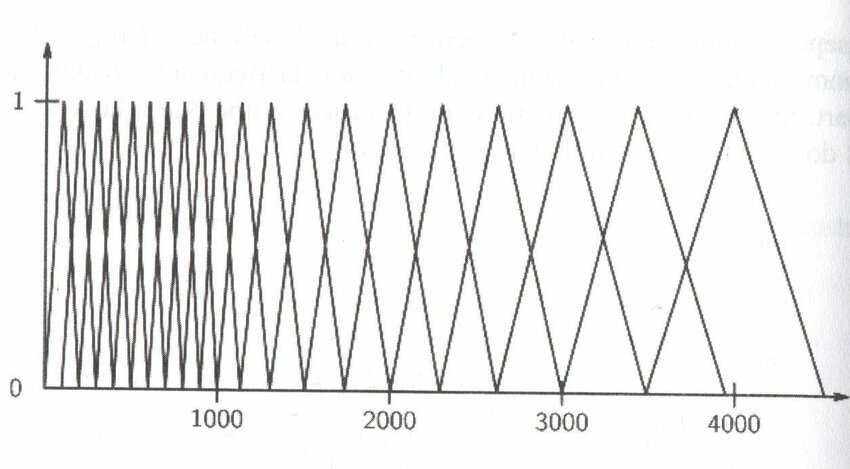

De la même manière, l'oreile ne perçoit pas l'amplitude de façon linéaire. Pour que le volume semble doublé, il faut que la puissance soit multiplié par 10.
On compresse la puissance spectrale sur une échelle logarithmique en décibels.

#### Formules

*Convertion des fréquences avec la formule d'O'Shaughnessy*

$$f_{\text{mel}} = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$

$f$ : fréquence réelle, $f_{\text{mel}}$ : fréquence perçue en Mel

***Construction du banc de filtres triangulaire $H_k(f)$***

On positionne K filtres triangulaires équidistants sur l'axe des mels (K=80 pour l'analyse vocale)

$H_k(f)$ : Poids d'atténuation appliqué à la fréquence $f$ par le $k$-ième filtre.

***Calcul de l'énergie de Mel $S[m,k]$***

A chaque trame temporelle $m$, on multiplie la puissance du spectre physique $|X[m,f]|²$ (obtenue par la STFT) par chaque filtre $H_k(f)$ pour obtenir l'énergie $S[m,k]$ de la $k$-ième bande de Mel : 

$$S[m, k] = \sum_{f} \vert{}X[m, f]\vert{}^2 \cdot H_k(f)$$

$m$ : Indice de la trame temporelle (instant $t$).

$k$ : Indice de la bande de Mel ($1 \le k \le K$).

$\vert{}X[m, f]\vert{}^2$ : Puissance spectrale physique à l'instant $m$ et à la fréquence $f$.

$S[m, k]$ : Énergie de Mel résultante (la valeur linéaire dans la matrice du Mel-spectrogramme).

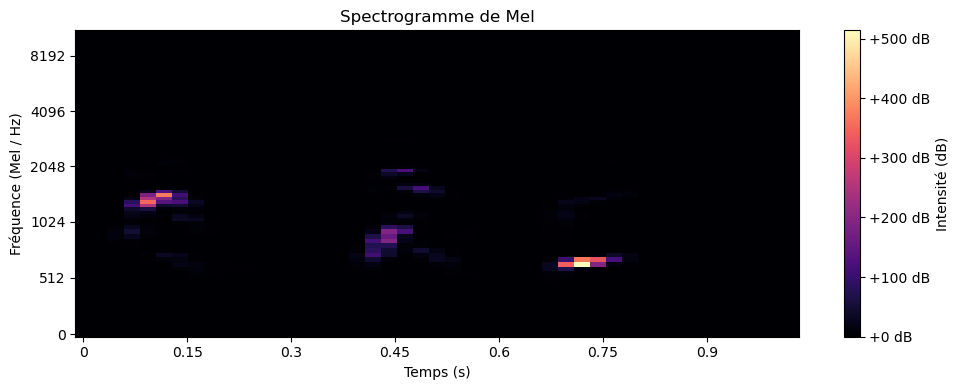

In [13]:
mel_spectrogram = librosa.feature.melspectrogram(
    y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=80
)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel_spectrogram,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format='%+2.0f dB', label='Intensité (dB)')
plt.title("Spectrogramme de Mel")
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Mel / Hz)")
plt.tight_layout()
plt.show()

***Passage à l'échelle logarithmique (dB)***

$$S_{\text{dB}}[m, k] = 10 \cdot \log_{10}\left(\frac{S[m, k]}{S_{\text{ref}}}\right)$$

$S[m, k]$ : Puissance spectrale

$S_{\text{ref}}$ : Valeur de référence (généralement max(S) pour placer le sommet à 0 dB)

**Ce code calcule la STFT et applique 80 filtres triangulaires de Mel**

***Paramètres***

$n\_mels=80$ : Nombre de bandes de filtres de Mel réparties sur le spectre (hyperparamètres optimisé pour la voix humaine)

***Output***

$mel\_spectrogram$ : tableau 2D de taille $(n\_mels, t) = (80, t)$ qui contient la puissance du signal après l'application des filtres de Mel. Chaque colonne est une trame temporelle

## Passage aux décibels

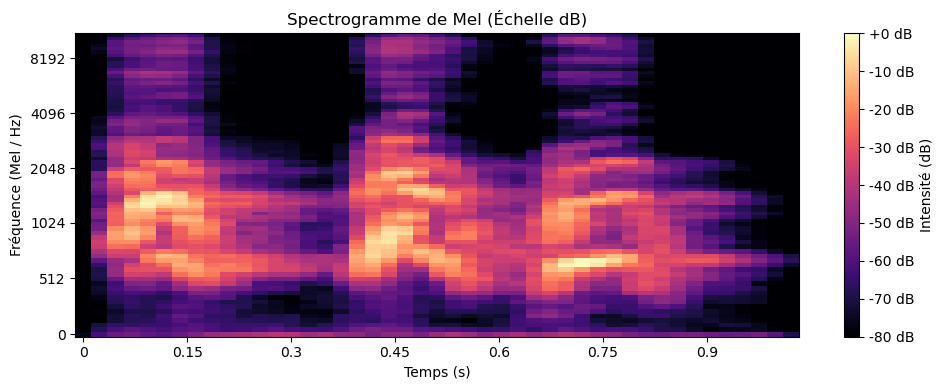

In [7]:
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

# 2. Affichage graphique
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mel_spectrogram_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB', label='Intensité (dB)')
plt.title("Spectrogramme de Mel (Échelle dB)")
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Mel / Hz)")
plt.tight_layout()
plt.show()

***Paramètres***

$ref=np.max$ : Référence normalisée 

***Output***

$mel\_spectrogram\_db$ : Matrice 2D de taille (n_mels, t) = (80, t) contenant les puissances en dB